In [1]:
#!pip install wandb -q
#!pip install timm -q
#!pip install torchvision
#!pip install matplotlib

In [2]:
# Log in to your W&B account
import wandb
import random
import math
import os
import logging

import sys

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

if not logger.handlers:

    console_handler = logging.StreamHandler(sys.stdout)  # ← fix
    file_handler = logging.FileHandler("run.log")

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(message)s"
    )

    console_handler.setFormatter(formatter)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)
logger.info("test")
logger.info("test2")

2026-04-13 07:21:55,231 | INFO | test
2026-04-13 07:21:55,232 | INFO | test2


In [3]:
os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/ubuntu/.netrc.
wandb: Currently logged in as: dpy8wq (vrb9e-university-of-virginia-school-of-data-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
import os, json, time, warnings
import wandb
import numpy as np
import pandas as pd
from PIL import Image

uvaid="dpy8wq"

import torch
import torch.nn as nn
 
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR #baseline
from torchvision import transforms #for iamge preprocessing, e.g. resize, augmentation etc
 
from sklearn.model_selection import GroupShuffleSplit #for lesion_id split later
 
warnings.filterwarnings("ignore")
logger.info("Imports OK")
import subprocess, zipfile
 
# PATHS 

DATA_ROOT = f"/home/ubuntu/{uvaid}/isic2019"
TEST_INPUT = f"{DATA_ROOT}/ISIC_2019_Test_Input"
TRAIN_INPUT = f"{DATA_ROOT}/ISIC_2019_Training_Input"
CKPT_DIR  = f"/home/ubuntu/{uvaid}/isic2019/checkpoints"

os.makedirs(DATA_ROOT, exist_ok=True)
 
BASE_URL = "https://isic-archive.s3.amazonaws.com/challenges/2019"
 

2026-04-13 07:21:59,380 | INFO | Imports OK


In [5]:
# Download CSVs & zips 
DOWNLOADS = [
    (f"{BASE_URL}/ISIC_2019_Training_GroundTruth.csv", f"{DATA_ROOT}/train_gt.csv"),
    (f"{BASE_URL}/ISIC_2019_Training_Metadata.csv",    f"{DATA_ROOT}/train_meta.csv"),
    (f"{BASE_URL}/ISIC_2019_Test_GroundTruth.csv",     f"{DATA_ROOT}/test_gt.csv"),
    (f"{BASE_URL}/ISIC_2019_Training_Input.zip",       f"{DATA_ROOT}/train_imgs.zip"),
    (f"{BASE_URL}/ISIC_2019_Test_Input.zip",           f"{DATA_ROOT}/test_imgs.zip"),
]


if not len([f for f in os.listdir(TEST_INPUT) if f.endswith('.jpg')]) == 8238 and \
    len([f for f in os.listdir(TRAIN_INPUT) if f.endswith('.jpg')]) == 25331:
    for url, dest in DOWNLOADS:
            logger.info(f"Downloading {os.path.basename(dest)} ...")
            subprocess.run(
                ["curl", "--location", "--progress-bar",
                 "--retry", "3", "--retry-delay", "5",
                 "--output", dest, url],
                check=True,
            )
    # Unzip
    for zip_path, extract_dir in [
        (f"{DATA_ROOT}/train_imgs.zip", DATA_ROOT),
        (f"{DATA_ROOT}/test_imgs.zip",  DATA_ROOT),
    ]:
        logger.info(f"Extracting {os.path.basename(zip_path)} ...")
        # Sanity check
        size_mb = os.path.getsize(zip_path) / (1024**2)
        logger.info(f"  File size: {size_mb:.1f} MB")
        if size_mb < 1:
            raise RuntimeError(f"File too small — download likely failed: {zip_path}")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)
        os.remove(zip_path)
        logger.info(f"  Done & removed {os.path.basename(zip_path)}")
else:
    logger.info('Data files already present, skipping download and unzip')

2026-04-13 07:21:59,395 | INFO | Data files already present, skipping download and unzip


In [6]:
# Path 
TRAIN_DIR  = os.path.join(DATA_ROOT, "ISIC_2019_Training_Input")
TEST_DIR   = os.path.join(DATA_ROOT, "ISIC_2019_Test_Input")
TRAIN_CSV  = os.path.join(DATA_ROOT, "train_gt.csv")
TEST_CSV   = os.path.join(DATA_ROOT, "test_gt.csv")
TRAIN_META = os.path.join(DATA_ROOT, "train_meta.csv")
 
logger.info("Done! Data ready.")

2026-04-13 07:21:59,400 | INFO | Done! Data ready.


In [7]:
Config = {
    # model
    "architecture": "mobilenet_v3_small",  # "resnet50" | "mobilenetv3_small" | efficientnet_b0
    "pretrained":   True,              # False = train from scratch ablation
    "freeze_bb":    False,             # True = head-only training ablation
    "loss_fn":      "weighted_ce",      # "ce" | "weighted_ce | "focal"
    "augmentation": "standard",           # "none" | "geometric" | "color" | "standard"
    "img_size":     224,
    "batch_size":   32,
    "epochs":       30,
    "lr":           1e-4,
    "val_split":    0.20,
    "patience":     10,                #stop epoch if no improvement for 10
    "seed":         42,                #set_seed for reproducibility 
    "classes":      ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"],
}
Config["num_classes"] = len(Config["classes"])
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Device: {device}")
logger.info(f"Config: {Config}")

2026-04-13 07:21:59,529 | INFO | Device: cuda
2026-04-13 07:21:59,530 | INFO | Config: {'architecture': 'mobilenet_v3_small', 'pretrained': True, 'freeze_bb': False, 'loss_fn': 'weighted_ce', 'augmentation': 'standard', 'img_size': 224, 'batch_size': 32, 'epochs': 30, 'lr': 0.0001, 'val_split': 0.2, 'patience': 10, 'seed': 42, 'classes': ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC'], 'num_classes': 8}


In [8]:
import random
def set_seed(seed=Config["seed"]):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
logger.info(f"Seed set to {Config['seed']}")

2026-04-13 07:21:59,539 | INFO | Seed set to 42


In [9]:
#Dataset 

class ISICDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(f"{self.img_dir}/{row['image']}.jpg").convert("RGB")
        
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label

def get_transforms(split):
    aug = Config["augmentation"]
    
    if split in ("val", "test"):
        return transforms.Compose([
            transforms.Resize((Config["img_size"], Config["img_size"])),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    
    # Train transforms vary by augmentation setting in the Config code cell
    if aug == "none":
        aug_tfms = []
    elif aug == "geometric":
        aug_tfms = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(degrees=15),
        ]
    elif aug == "color":
        aug_tfms = [
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        ]
    elif aug == "standard":
        aug_tfms = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.RandomRotation(degrees=15),
        ]
    
    return transforms.Compose([
        transforms.Resize((Config["img_size"], Config["img_size"])),
        *aug_tfms,
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

In [10]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small

# Load pretrained model
model = mobilenet_v3_small(weights="IMAGENET1K_V1")

# Replace classifier for your dataset
num_classes = 10  # change this!
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

In [11]:
# import torch.nn as nn
# from torchvision.models import mobilenet_v3_small

def build_model(num_classes=Config["num_classes"]):
    weights = "IMAGENET1K_V1" if Config["pretrained"] else None
    
    model = mobilenet_v3_small(weights=weights)
    
    # Replace classifier
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    
    return model

model = build_model().to(device)

logger.info(type(model))
logger.info("Model loaded OK")

2026-04-13 07:21:59,890 | INFO | <class 'torchvision.models.mobilenetv3.MobileNetV3'>
2026-04-13 07:21:59,891 | INFO | Model loaded OK


In [12]:
#os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
 
wandb.init(
    entity="vrb9e-university-of-virginia-school-of-data-science",
    project="ISIC2019",
    name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
    config={
        "architecture":  Config["architecture"],
        "loss_fn":       Config["loss_fn"],
        "augmentation":  Config["augmentation"],
        "pretrained":    Config["pretrained"],
        "freeze_bb":     Config["freeze_bb"],
        "img_size":      Config["img_size"],
        "batch_size":    Config["batch_size"],
        "epochs":        Config["epochs"],
        "lr":            Config["lr"],
        "val_split":     Config["val_split"],
        "patience":      Config["patience"],
        "seed":          Config["seed"],
    }
)

### TRAINING LOOP - ONE_EPOCH

In [13]:
import torch.nn.functional as F
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [14]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)                        
            probs   = F.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())       

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc  = (all_preds == all_labels).mean()
    bacc = balanced_accuracy_score(all_labels, all_preds)

    # sensitivity & specificity per class
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(Config["num_classes"])))
    sensitivity, specificity, f1_per = [], [], []
    for i in range(Config["num_classes"]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sensitivity.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_per.append(2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0)

    # AUC per class
    auc_per_class = {}
    for i, cls in enumerate(Config["classes"]):
        try:
            auc_per_class[cls] = roc_auc_score((all_labels == i).astype(int), all_probs[:, i])
        except ValueError:
            auc_per_class[cls] = float("nan")

    return acc, bacc, np.array(sensitivity), np.array(specificity), np.array(f1_per), auc_per_class

In [15]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

# Convert label column
train_df["label"] = train_df[Config["classes"]].values.argmax(axis=1)
test_df["label"]  = test_df[Config["classes"]].values.argmax(axis=1)

# Train/val split stratified by label...to be improved later by adding patient-level split with lesion_id(GroupShuffleSplit)
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    train_df,
    test_size=Config["val_split"],
    stratify=train_df["label"],
    random_state=Config["seed"],
)

logger.info(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

2026-04-13 07:22:01,301 | INFO | Train: 20264 | Val: 5067 | Test: 8238


In [16]:
#show class imabalnce in frequency table
counts        = train_df["label"].value_counts().sort_index()
CLASS_FREQ    = (counts / counts.sum()).to_dict()

logger.info("Class frequencies:")

for name, df_ in [("TRAIN", train_df), ("VAL", val_df)]:
    labels = df_[Config["classes"]].values.argmax(axis=1)
    cnts   = np.bincount(labels, minlength=len(Config["classes"]))

    logger.info(f"\n{name} ({len(df_)} images):")
    for i, c in enumerate(Config["classes"]):
        logger.info(f"  {c:6s}: {cnts[i]:5d}  ({100*cnts[i]/len(df_):4.1f}%)")

2026-04-13 07:22:01,309 | INFO | Class frequencies:
2026-04-13 07:22:01,314 | INFO | 
TRAIN (20264 images):
2026-04-13 07:22:01,314 | INFO |   MEL   :  3618  (17.9%)
2026-04-13 07:22:01,315 | INFO |   NV    : 10300  (50.8%)
2026-04-13 07:22:01,316 | INFO |   BCC   :  2658  (13.1%)
2026-04-13 07:22:01,316 | INFO |   AK    :   694  ( 3.4%)
2026-04-13 07:22:01,317 | INFO |   BKL   :  2099  (10.4%)
2026-04-13 07:22:01,318 | INFO |   DF    :   191  ( 0.9%)
2026-04-13 07:22:01,318 | INFO |   VASC  :   202  ( 1.0%)
2026-04-13 07:22:01,319 | INFO |   SCC   :   502  ( 2.5%)
2026-04-13 07:22:01,320 | INFO | 
VAL (5067 images):
2026-04-13 07:22:01,321 | INFO |   MEL   :   904  (17.8%)
2026-04-13 07:22:01,322 | INFO |   NV    :  2575  (50.8%)
2026-04-13 07:22:01,323 | INFO |   BCC   :   665  (13.1%)
2026-04-13 07:22:01,323 | INFO |   AK    :   173  ( 3.4%)
2026-04-13 07:22:01,324 | INFO |   BKL   :   525  (10.4%)
2026-04-13 07:22:01,324 | INFO |   DF    :    48  ( 0.9%)
2026-04-13 07:22:01,325 | I

In [17]:
# 10% subset TO REMOVE LATER
frac = 0.01
train_df = train_df.sample(frac=frac, random_state=Config["seed"]).reset_index(drop=True)
val_df   = val_df.sample(frac=frac,   random_state=Config["seed"]).reset_index(drop=True)
test_df  = test_df.sample(frac=frac,  random_state=Config["seed"]).reset_index(drop=True)
logger.info(f"Subset — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# Datasets
train_ds = ISICDataset(train_df, TRAIN_DIR, get_transforms("train"))
val_ds   = ISICDataset(val_df,   TRAIN_DIR, get_transforms("val"))
test_ds  = ISICDataset(test_df,  TEST_DIR,  get_transforms("test"))

# Dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=Config["batch_size"],
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=Config["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=Config["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

2026-04-13 07:22:01,337 | INFO | Subset — train: 203, val: 51, test: 82


In [18]:
# compute class weights from standard ce so we can address class imbalance
# counts = train_df["label"].value_counts().sort_index()
counts = train_df["label"].value_counts().sort_index()
class_weights = (1.0 / counts).values
class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalize
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# build loss from Config
if Config["loss_fn"] == "weighted_ce":
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
elif Config["loss_fn"] == "ce":
    loss_fn = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unknown loss_fn: {Config['loss_fn']}")

In [19]:
logger.info(f"Class counts: {counts}")
logger.info(f"Total samples: {counts.sum()}")
logger.info(f"Raw inverse weights: { ((1.0 / counts).values)}")
logger.info(f"Normalized class weights: {class_weights}")
logger.info(f"Sum of weights: {class_weights.sum().item()}")
for cls, w in zip(counts.index, class_weights):
    logger.info(f"Class {cls}: count={counts[cls]}, weight={w.item():.4f}")

logger.info("Loss function: {loss_fn}")
if hasattr(loss_fn, "weight") and loss_fn.weight is not None:
    logger.info("Loss weights: {loss_fn.weight}")
    
sorted_unique = sorted( train_df["label"].unique() )
logger.info(f"Unique labels: {sorted_unique}")

2026-04-13 07:22:01,355 | INFO | Class counts: label
0     38
1    107
2     29
3      4
4     17
5      1
6      3
7      4
Name: count, dtype: int64
2026-04-13 07:22:01,356 | INFO | Total samples: 203
2026-04-13 07:22:01,357 | INFO | Raw inverse weights: [0.02631579 0.00934579 0.03448276 0.25       0.05882353 1.
 0.33333333 0.25      ]
2026-04-13 07:22:01,499 | INFO | Normalized class weights: tensor([0.1073, 0.0381, 0.1406, 1.0192, 0.2398, 4.0768, 1.3589, 1.0192],
       device='cuda:0')
2026-04-13 07:22:01,509 | INFO | Sum of weights: 7.999999523162842
2026-04-13 07:22:01,510 | INFO | Class 0: count=38, weight=0.1073
2026-04-13 07:22:01,511 | INFO | Class 1: count=107, weight=0.0381
2026-04-13 07:22:01,512 | INFO | Class 2: count=29, weight=0.1406
2026-04-13 07:22:01,512 | INFO | Class 3: count=4, weight=1.0192
2026-04-13 07:22:01,513 | INFO | Class 4: count=17, weight=0.2398
2026-04-13 07:22:01,513 | INFO | Class 5: count=1, weight=4.0768
2026-04-13 07:22:01,514 | INFO | Class 6: 

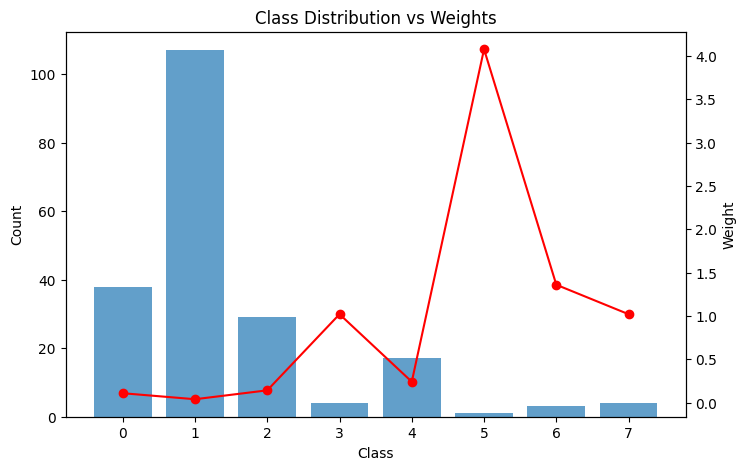

In [20]:
import matplotlib.pyplot as plt

labels = counts.index.tolist()
counts_values = counts.values
weights_values = class_weights.cpu().numpy()

fig, ax1 = plt.subplots(figsize=(8, 5))

# Counts (left axis)
ax1.bar(labels, counts_values, alpha=0.7)
ax1.set_xlabel("Class")
ax1.set_ylabel("Count")
ax1.set_title("Class Distribution vs Weights")

# Weights (right axis)
ax2 = ax1.twinx()
ax2.plot(labels, weights_values, color='red', marker='o')
ax2.set_ylabel("Weight")

plt.show()

In [21]:
'''
import numpy as np

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, counts_values, width, label='Counts')
plt.bar(x + width/2, weights_values, width, label='Weights')

plt.xticks(x, labels)
plt.xlabel("Class")
plt.title("Counts vs Class Weights")
plt.legend()
plt.show()
'''

'\nimport numpy as np\n\nx = np.arange(len(labels))\nwidth = 0.35\n\nplt.figure(figsize=(8, 5))\nplt.bar(x - width/2, counts_values, width, label=\'Counts\')\nplt.bar(x + width/2, weights_values, width, label=\'Weights\')\n\nplt.xticks(x, labels)\nplt.xlabel("Class")\nplt.title("Counts vs Class Weights")\nplt.legend()\nplt.show()\n'

In [22]:
'''
plt.figure(figsize=(8, 5))
plt.bar(labels, counts_values)
plt.yscale('log')
plt.title("Class Distribution (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Count (log scale)")
plt.show()
'''

'\nplt.figure(figsize=(8, 5))\nplt.bar(labels, counts_values)\nplt.yscale(\'log\')\nplt.title("Class Distribution (Log Scale)")\nplt.xlabel("Class")\nplt.ylabel("Count (log scale)")\nplt.show()\n'

In [23]:
'''
inv = 1.0 / counts_values

plt.plot(labels, inv, label="1/count")
plt.plot(labels, weights_values, label="normalized weights")
plt.legend()
plt.title("Raw vs Normalized Weights")
plt.show()
'''

'\ninv = 1.0 / counts_values\n\nplt.plot(labels, inv, label="1/count")\nplt.plot(labels, weights_values, label="normalized weights")\nplt.legend()\nplt.title("Raw vs Normalized Weights")\nplt.show()\n'

### TRAINING LOOP - EPOCHS

In [24]:
#os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
 
wandb.init(
    entity="vrb9e-university-of-virginia-school-of-data-science",
    project="ISIC2019",
    name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
    config={
        "architecture":  Config["architecture"],
        "loss_fn":       Config["loss_fn"],
        "augmentation":  Config["augmentation"],
        "pretrained":    Config["pretrained"],
        "freeze_bb":     Config["freeze_bb"],
        "img_size":      Config["img_size"],
        "batch_size":    Config["batch_size"],
        "epochs":        Config["epochs"],
        "lr":            Config["lr"],
        "val_split":     Config["val_split"],
        "patience":      Config["patience"],
        "seed":          Config["seed"],
    }
)

In [27]:
model     = build_model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config["lr"])
scheduler = CosineAnnealingLR(optimizer, T_max=Config["epochs"], eta_min=1e-6)

best_bacc, best_epoch, no_improve = -1, 0, 0
history   = []
os.makedirs(CKPT_DIR, exist_ok=True)
ckpt_path = os.path.join(CKPT_DIR, "mobilenet_v3_small_best.pt")

logger.info(f"Training | pretrained={Config['pretrained']} | loss={Config['loss_fn']}\n")
t0 = time.time()

for epoch in range(1, Config["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    acc, bacc, sensitivity, specificity, f1_per, auc_per_class = evaluate(model, val_loader, device)

    auc_macro = np.nanmean(list(auc_per_class.values()))
    
    log_dict = {
        "epoch":                 epoch,
        "train/loss":            train_loss,
        "val/acc":               acc,
        "val/bacc":              bacc,
        "val/sensitivity_macro": sensitivity.mean(),
        "val/specificity_macro": specificity.mean(),
        "val/f1_macro":          f1_per.mean(),
        "val/auc_macro":         auc_macro,
    }
    for i, cls in enumerate(Config["classes"]):
        log_dict[f"val/sensitivity_{cls}"] = sensitivity[i]
        log_dict[f"val/specificity_{cls}"] = specificity[i]
        log_dict[f"val/f1_{cls}"]          = f1_per[i]
        log_dict[f"val/auc_{cls}"]         = auc_per_class[cls]   # per-class AUC

    wandb.log(log_dict)
    
    history.append({
        "epoch":      epoch,
        "train_loss": train_loss,
        
        "val_acc":    acc,
        "val_bacc":   bacc,
        
        "val_sens":   float(sensitivity.mean()),
        "val_spec":   float(specificity.mean()),
        
        "val_f1":     float(f1_per.mean()),
        "val_auc":    float(auc_macro),
    })

    logger.info(f"Epoch {epoch:3d}/{Config['epochs']} | loss={train_loss:.4f} | "
          f"acc={acc:.4f} | bacc={bacc:.4f} | "
          f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
          f"f1={f1_per.mean():.4f} | auc={auc_macro:.4f}")

    scheduler.step()

    if bacc > best_bacc:
        best_bacc, best_epoch = bacc, epoch
        no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        logger.info("saved")
    else:
        no_improve += 1
        logger.info(f"  (no improve {no_improve}/{Config['patience']})")
        if no_improve >= Config["patience"]:
            logger.info(f"\nEarly stopping at epoch {epoch}.")
            break

# logger.info AUC after last epoch
logger.info("\nPer-class AUC:")
for cls in Config["classes"]:
    auc_val = auc_per_class.get(cls, float("nan"))
    logger.info(f"  {cls}: {auc_val:.4f}")
logger.info("")

logger.info(f"\nDone in {(time.time()-t0)/60:.1f} min")

logger.info(f"Best   | epoch={best_epoch} | bacc={best_bacc:.4f}")
logger.info(f"Final  | acc={acc:.4f} | bacc={bacc:.4f} | "
      f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
      f"f1={f1_per.mean():.4f} | auc={auc_macro:.4f}")

history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
logger.info(f"History saved to {history_path}")

2026-04-13 07:25:58,906 | INFO | Training | pretrained=True | loss=weighted_ce

2026-04-13 07:26:01,505 | INFO | Epoch   1/30 | loss=2.1033 | acc=0.1176 | bacc=0.1503 | sens=0.0939 | spec=0.8772 | f1=0.0394 | auc=0.4164
2026-04-13 07:26:01,801 | INFO | saved
2026-04-13 07:26:04,427 | INFO | Epoch   2/30 | loss=1.9202 | acc=0.1765 | bacc=0.2148 | sens=0.1343 | spec=0.8832 | f1=0.0553 | auc=0.4440
2026-04-13 07:26:04,462 | INFO | saved
2026-04-13 07:26:07,111 | INFO | Epoch   3/30 | loss=1.8253 | acc=0.1765 | bacc=0.2148 | sens=0.1343 | spec=0.8799 | f1=0.0531 | auc=0.4531
2026-04-13 07:26:07,112 | INFO |   (no improve 1/10)
2026-04-13 07:26:09,667 | INFO | Epoch   4/30 | loss=1.6654 | acc=0.1961 | bacc=0.2648 | sens=0.1655 | spec=0.8765 | f1=0.1021 | auc=0.4686
2026-04-13 07:26:09,700 | INFO | saved
2026-04-13 07:26:12,279 | INFO | Epoch   5/30 | loss=1.6110 | acc=0.2157 | bacc=0.2722 | sens=0.1701 | spec=0.8800 | f1=0.1100 | auc=0.4840
2026-04-13 07:26:12,313 | INFO | saved
2026-04-13 

In [ ]:
'''
import random
import math
os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"

# Launch 5 simulated experiments
total_runs = 5
for run in range(total_runs):
  # 1️. Start a new run to track this script
  wandb.init(
      # Set the project where this run will be logged
      project="basic-intro",
      # We pass a run name (otherwise it’ll be randomly assigned, like sunshine-lollypop-10)
      name=f"experiment_{run}",
      # Track hyperparameters and run metadata
      config={
      "learning_rate": 0.02,
      "architecture": "CNN",
      "dataset": "CIFAR-100",
      "epochs": 10,
      })

  # This simple block simulates a training loop logging metrics
  epochs = 10
  offset = random.random() / 5
  for epoch in range(2, epochs):
      acc = 1 - 2 ** -epoch - random.random() / epoch - offset
      loss = 2 ** -epoch + random.random() / epoch + offset

      # 2️. Log metrics from your script to W&B
      wandb.log({"acc": acc, "loss": loss})

  # Mark the run as finished
  wandb.finish()
  '''

In [29]:
'''
model     = build_model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config["lr"])
scheduler = CosineAnnealingLR(optimizer, T_max=Config["epochs"], eta_min=1e-6)

best_bacc, best_epoch, no_improve = -1, 0, 0
history   = []
ckpt_path = os.path.join(CKPT_DIR, "mbv3-small_best.pt")

logger.info(f"Training | pretrained={Config['pretrained']} | loss={Config['loss_fn']}\n")
t0 = time.time()

for epoch in range(1, Config["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    acc, bacc, sensitivity, specificity, f1_per, auc_per_class = evaluate(model, val_loader, device)

    auc_macro = np.nanmean(list(auc_per_class.values()))
    
    log_dict = {
        "epoch":                 epoch,
        "train/loss":            train_loss,
        "val/acc":               acc,
        "val/bacc":              bacc,
        "val/sensitivity_macro": sensitivity.mean(),
        "val/specificity_macro": specificity.mean(),
        "val/f1_macro":          f1_per.mean(),
        "val/auc_macro":         auc_macro,
    }
    for i, cls in enumerate(Config["classes"]):
        log_dict[f"val/sensitivity_{cls}"] = sensitivity[i]
        log_dict[f"val/specificity_{cls}"] = specificity[i]
        log_dict[f"val/f1_{cls}"]          = f1_per[i]
        log_dict[f"val/auc_{cls}"]         = auc_per_class[cls]   # per-class AUC


#os.environ["WANDB_NOTEBOOK_NAME"] = "mbv3-small.ipynb"
 
    wandb.init(
        entity="vrb9e-university-of-virginia-school-of-data-science",
        project="ISIC2019",
        name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
        config={
            "architecture":  Config["architecture"],
            "loss_fn":       Config["loss_fn"],
            "augmentation":  Config["augmentation"],
            "pretrained":    Config["pretrained"],
            "freeze_bb":     Config["freeze_bb"],
            "img_size":      Config["img_size"],
            "batch_size":    Config["batch_size"],
            "epochs":        Config["epochs"],
            "lr":            Config["lr"],
            "val_split":     Config["val_split"],
            "patience":      Config["patience"],
            "seed":          Config["seed"],
        }
    )

    wandb.log(log_dict)
    
    history.append({
        "epoch":      epoch,
        "train_loss": train_loss,
        
        "val_acc":    acc,
        "val_bacc":   bacc,
        
        "val_sens":   float(sensitivity.mean()),
        "val_spec":   float(specificity.mean()),
        
        "val_f1":     float(f1_per.mean()),
        "val_auc":    float(auc_macro),
    })

'''

'''
    logger.info(f"Epoch {epoch:3d}/{Config['epochs']} | loss={train_loss:.4f} | "
          f"acc={acc:.4f} | bacc={bacc:.4f} | "
          f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
          f"f1={f1_per.mean():.4f} | auc={auc_macro:.4f}", end="")
    
    scheduler.step()

    if bacc > best_bacc:
        best_bacc, best_epoch = bacc, epoch
        no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        logger.info("saved")
    else:
        no_improve += 1
        logger.info(f"  (no improve {no_improve}/{Config['patience']})")
        if no_improve >= Config["patience"]:
            logger.info(f"\nEarly stopping at epoch {epoch}.")
            break
'''

logger.info(f"\nDone in {(time.time()-t0)/60:.1f} min")

logger.info(f"Best   | epoch={best_epoch} | bacc={best_bacc:.4f}")
logger.info(f"Final  | acc={acc:.4f} | bacc={bacc:.4f} | "
      f"sens={sensitivity.mean():.4f} | spec={specificity.mean():.4f} | "
      f"f1={f1_per.mean():.4f} | auc={auc_macro:.4f}")

# logger.info AUC after last epoch
logger.info("\nPer-class AUC:")
for cls in Config["classes"]:
    auc_val = auc_per_class.get(cls, float("nan"))
    logger.info(f"  {cls}: {auc_val:.4f} |")
logger.info("")

history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
logger.info(f"History saved to {history_path}")


2026-04-13 07:28:00,503 | INFO | 
Done in 2.0 min
2026-04-13 07:28:00,504 | INFO | Best   | epoch=9 | bacc=0.2774
2026-04-13 07:28:00,506 | INFO | Final  | acc=0.3725 | bacc=0.2681 | sens=0.1676 | spec=0.9038 | f1=0.1536 | auc=0.5859
2026-04-13 07:28:00,507 | INFO | 
Per-class AUC:
2026-04-13 07:28:00,508 | INFO |   MEL: 0.7386 |
2026-04-13 07:28:00,508 | INFO |   NV: 0.7392 |
2026-04-13 07:28:00,509 | INFO |   BCC: 0.8636 |
2026-04-13 07:28:00,510 | INFO |   AK: nan |
2026-04-13 07:28:00,510 | INFO |   BKL: 0.5266 |
2026-04-13 07:28:00,511 | INFO |   DF: nan |
2026-04-13 07:28:00,512 | INFO |   VASC: nan |
2026-04-13 07:28:00,512 | INFO |   SCC: 0.0612 |
2026-04-13 07:28:00,513 | INFO | 
2026-04-13 07:28:00,515 | INFO | History saved to /home/ubuntu/dpy8wq/isic2019/checkpoints/history.json


In [30]:
def print_benchmark(model, label="Model"):
    params_total     = sum(p.numel() for p in model.parameters())
    params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb          = params_total * 4 / 1024 ** 2  # float32

    # Inference speed
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)
    with torch.no_grad():
        start = torch.cuda.Event(enable_timing=True)
        end   = torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(50):
            model(dummy)
        end.record()
        torch.cuda.synchronize()
    inference_ms = start.elapsed_time(end) / 50

    # GFLOPs (requires thop)
    try:
        from thop import profile
        flops, _ = profile(model, inputs=(dummy,), verbose=False)
        gflops = flops / 1e9
    except:
        gflops = None

    bench = {
        "params_total":     params_total,
        "params_trainable": params_trainable,
        "size_mb":          round(size_mb, 2),
        "inference_ms":     round(inference_ms, 2),
        "gflops":           round(gflops, 4) if gflops else None
    }

    logger.info(f"\n=== Benchmark: {label} ===")
    for k, v in bench.items():
        logger.info(f"  {k}: {v}")

    return bench

 
wandb.init(
    entity="vrb9e-university-of-virginia-school-of-data-science",
    project="ISIC2019",
    name=f"{Config['architecture']}_{Config['loss_fn']}_{Config['augmentation']}_pretrained{Config['pretrained']}",
    config={
        "architecture":  Config["architecture"],
        "loss_fn":       Config["loss_fn"],
        "augmentation":  Config["augmentation"],
        "pretrained":    Config["pretrained"],
        "freeze_bb":     Config["freeze_bb"],
        "img_size":      Config["img_size"],
        "batch_size":    Config["batch_size"],
        "epochs":        Config["epochs"],
        "lr":            Config["lr"],
        "val_split":     Config["val_split"],
        "patience":      Config["patience"],
        "seed":          Config["seed"],
    }
)

model.load_state_dict(torch.load(ckpt_path, map_location=device))
bench = print_benchmark(model, label=f"mobilenet_v3_small ({Config['loss_fn']}, aug={Config['augmentation']})")
wandb.summary["benchmark/params_total"]     = bench["params_total"]
wandb.summary["benchmark/params_trainable"] = bench["params_trainable"]
wandb.summary["benchmark/size_mb"]          = bench["size_mb"]
wandb.summary["benchmark/inference_ms"]     = bench["inference_ms"]
wandb.summary["benchmark/gflops"]           = bench["gflops"]
wandb.summary["best_val_bacc"]              = best_bacc
wandb.summary["best_epoch"]                 = best_epoch
artifact = wandb.Artifact(
    name=f"efficientnet_b0_{Config['loss_fn']}_{Config['augmentation']}",
    type="model",
    description=f"Best checkpoint — val BACC {best_bacc:.4f} @ epoch {best_epoch}"
)
artifact.add_file(ckpt_path)
wandb.log_artifact(artifact)
logger.info("Checkpoint artifact logged to W&B")
wandb.finish()
logger.info("W&B run finished.")

# History saving
history_path = os.path.join(CKPT_DIR, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
logger.info(f"History saved to {history_path}")

epoch,▁▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇█
train/loss,██▇▇▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂█▇▆▅▅▅▄▄▄▃▃▂▂▂▂▁▂▁▁
val/acc,▁▁▂▃▃▃▃▄▆▇████▇██████▃▄▄▄▅▅▅▆▇▆▆▆▆▇▇▇▇██
val/auc_BCC,▁▄▅▅▆▆▆▇▇▇▇▇▇▇███████▅▆▆▇▇▇▇▇▇██████████
val/auc_BKL,▅▃▃▃▃▄▄▄▄▄▄▄▄▂▂▂▂▂▂▁▁▇▇▆▆▇█▇▇▇████▇▇▆▆▅▅
val/auc_MEL,▃▃▃▃▄▅▅▅▆▆▆▆▇▇▇▇▆▆▆▆▆▁▂▂▂▃▃▄▄▅▅▆▆▇▇█████
val/auc_NV,▁▅▅▅▅▅▅▅▄▄▄▄▅▅▅▅▅▆▆▆▆▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
val/auc_SCC,▁▇███▇▇▇▆▆▆▅▅▅▅▄▄▄▄▄▄▁▁▁▁▁▁▁▂▂▂▁▁▁▁▁▁▁▁▁
val/auc_macro,▁▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▃▄▄▅▅▆▆▆▇▇▇▇███████
val/bacc,▁▁▂▄▄▅▅▄▇▇████▇▇▇▇▇▇▇▅▆▆██▇▇███▆▆▇▇▇▇▇▇█
+30,...


2026-04-13 07:28:19,730 | INFO | 
=== Benchmark: mobilenet_v3_small (weighted_ce, aug=standard) ===
2026-04-13 07:28:19,731 | INFO |   params_total: 1526056
2026-04-13 07:28:19,732 | INFO |   params_trainable: 1526056
2026-04-13 07:28:19,732 | INFO |   size_mb: 5.82
2026-04-13 07:28:19,733 | INFO |   inference_ms: 5.43
2026-04-13 07:28:19,734 | INFO |   gflops: None
2026-04-13 07:28:20,673 | INFO | Checkpoint artifact logged to W&B


benchmark/inference_ms,5.43
benchmark/params_total,1526056
benchmark/params_trainable,1526056
benchmark/size_mb,5.82
best_epoch,9
best_val_bacc,0.27744


2026-04-13 07:28:23,781 | INFO | W&B run finished.
2026-04-13 07:28:23,784 | INFO | History saved to /home/ubuntu/dpy8wq/isic2019/checkpoints/history.json


In [ ]:
print(logging.INFO)